# Bivariate Gaussian Distributions Using Real CPT Data


## Part 1: Geotechnical background and data

### What is a CPT?

The **Cone Penetration Test (CPT)** is an *in-situ* geotechnical test. A cone-shaped probe is pushed vertically into the ground at a controlled rate while soil resistance is measured continuously with depth. Because measurements are obtained at closely spaced depth intervals, a CPT provides a detailed profile of changes in ground conditions.

In this workshop we deliberately consider only **two measurements**:

- **Cone resistance, $q_c$ [MPa]** — resistance acting on the cone tip. Larger values generally indicate greater resistance of the soil to penetration.
- **Sleeve friction, $f_s$ [MPa]** — friction acting along the sleeve immediately behind the cone.

Both measurements respond to the soil encountered by the probe. They may therefore vary together and provide a useful real engineering example for studying **covariance, correlation, joint probability distributions, and conditional distributions**.

> A CPT can contain other measurements, but these are intentionally not introduced here. No prior geotechnical knowledge is required.

### The real dataset

The dataset is a **real CPT profile from the Netherlands**, extending to approximately **15 m below ground level**, with measurements at roughly 0.02 m intervals.

For this workshop we use all available paired $q_c$ and $f_s$ measurements over the **full profile**.




In [1]:
import pandas as pd
import numpy as np
from scipy.stats import multivariate_normal
from scipy.stats import norm
import matplotlib.pyplot as plt
from statistics import mean, stdev

In [2]:
import os
from urllib.request import urlretrieve

def findfile(fname):
    if not os.path.isfile(fname):
        print(f'Downloading {fname}...')
        urlretrieve('https://github.com/TUDelft-MUDE/source-files/raw/main/file/'+fname, fname)

findfile('CPT_data.csv')

Number of paired observations: 743
Depth range: 0.10–14.92 m
[[ 1.37   0.037]
 [ 1.685  0.041]
 [ 1.96   0.045]
 ...
 [17.704  0.129]
 [17.266  0.131]
 [16.427  0.131]]


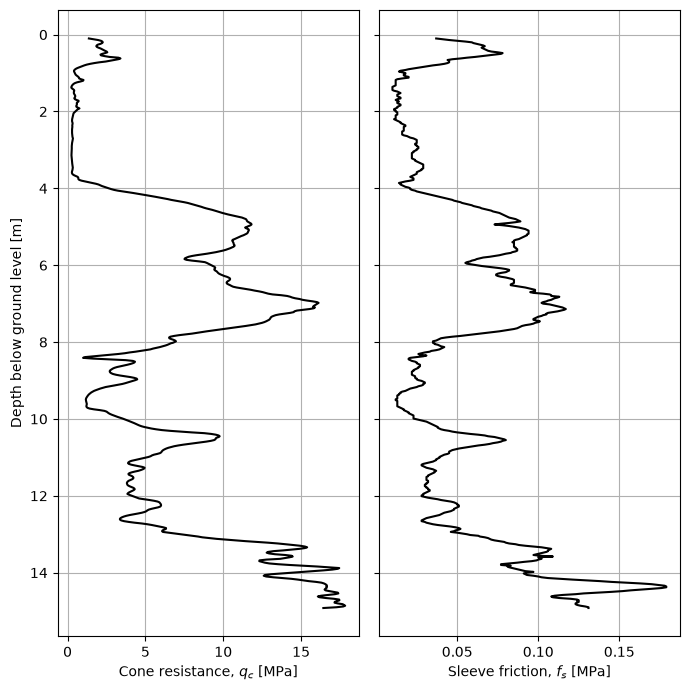

In [3]:
dataframe = pd.read_csv('CPT_data.csv')

# Only the variables required for this workshop
cpt = dataframe[['depth_m', 'qc_MPa', 'fs_MPa']].dropna()

# Inspect the real CPT profile
fig, axes = plt.subplots(1, 2, figsize=(7,7), sharey=True)
axes[0].plot(cpt['qc_MPa'], cpt['depth_m'], 'k')
axes[0].set_xlabel(r'Cone resistance, $q_c$ [MPa]')
axes[0].set_ylabel('Depth below ground level [m]')
axes[0].grid()

axes[1].plot(cpt['fs_MPa'], cpt['depth_m'], 'k')
axes[1].set_xlabel(r'Sleeve friction, $f_s$ [MPa]')
axes[1].grid()

axes[0].invert_yaxis()
plt.tight_layout()

# Use the complete set of paired qc-fs measurements
data = cpt[['qc_MPa', 'fs_MPa']].to_numpy()

print('Number of paired observations:', len(data))
print('Depth range: {:.2f}–{:.2f} m'.format(cpt.depth_m.min(), cpt.depth_m.max()))
print(data)


## Part 2: Covariance and correlation

> **Task 2.1: Explore dependence**
>
> Plot cone resistance $q_c$ against sleeve friction $f_s$ for the **whole CPT profile**.
>
> Based on the scatter plot:
>
> 1. Do larger values of $q_c$ generally occur together with larger values of $f_s$?
> 2. Would you expect these two measurements to be statistically independent?


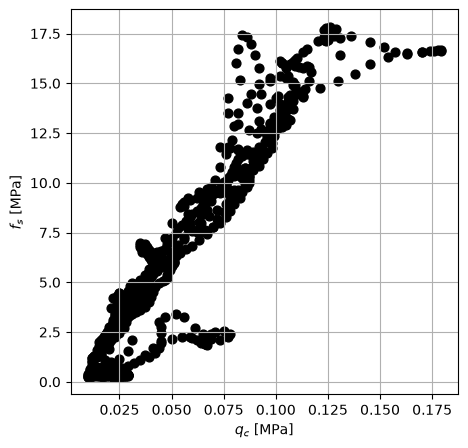

In [5]:
fig, ax = plt.subplots(figsize=(5,5))
ax.scatter(cpt['fs_MPa'],cpt['qc_MPa'],40, 'k')
ax.set_ylabel(r'$f_s$ [MPa]')
ax.set_xlabel(r'$q_c$ [MPa]')
ax.grid()


> **Task 2.2:**
>
> It looks like a relationship exists between the two CPT variables. Let's quantify it.
>
> Define a function that calculates the covariance between two variables. The function must take the two vectors of observations as input and return the covariance.
>
> Apply the function to calculate the covariance between $q_c$ and $f_s$. Interpret both the **sign** and **magnitude** of the covariance.
>
> *Important: code the function yourself; do not use a prebuilt covariance function.*


In [ ]:
def calculate_covariance(X1, X2):
    """Calculate the sample covariance between two variables."""

    # Step 1: calculate the sample means
    mean_x1 = ### YOUR CODE HERE ###
    mean_x2 = ### YOUR CODE HERE ###

    # Step 2: calculate deviations from the means
    diff_x1 = ### YOUR CODE HERE ###
    diff_x2 = ### YOUR CODE HERE ###

    # Step 3: multiply corresponding deviations
    product = ### YOUR CODE HERE ###

    # Step 4: calculate the sample covariance
    # Hint: because these are sample observations, use N - 1
    covariance = ### YOUR CODE HERE ###

    return covariance

# Apply the function to the CPT data
covariance_qc_fs = ### YOUR CODE HERE ###
print('The covariance between qc and fs is',
      np.round(covariance_qc_fs, 5), 'MPa²')


> **Task 2.3:**
>
> Define a function that calculates Pearson's correlation coefficient between two variables.
>
> Apply the function to the CPT dataset and calculate the correlation coefficient between $q_c$ and $f_s$. Interpret the result and compare its usefulness with covariance.
>
> *Hint: you may reuse the covariance function defined above.*


In [ ]:
def pearson_correlation(X1, X2):
    """Calculate the Pearson correlation coefficient."""

    # Step 1: calculate covariance
    covariance = ### YOUR CODE HERE ###

    # Step 2: calculate the sample standard deviations
    std_x1 = ### YOUR CODE HERE ###
    std_x2 = ### YOUR CODE HERE ###

    # Step 3: standardize the covariance
    correl_coeff = ### YOUR CODE HERE ###

    return correl_coeff

# Apply the function to the CPT data
correlation_qc_fs = ### YOUR CODE HERE ###
print("Pearson's correlation coefficient between qc and fs is",
      np.round(correlation_qc_fs, 2))


## Part 3: Bivariate Gaussian distribution

> **Task 3.1: Fit a bivariate Gaussian distribution**
>
> Approximate the joint distribution of $q_c$ and $f_s$ using a **bivariate Gaussian distribution**.
>
> - Estimate the mean vector.
> - Estimate the covariance matrix.
> - Generate 100 random pairs $(q_c,f_s)$.
> - Compare the generated samples with the real CPT observations.
>
> Does one elliptical Gaussian cloud reproduce the real observations well?


In [ ]:
# Construct the mean vector
mu1 = ### YOUR CODE HERE ###  # mean cone resistance qc
mu2 = ### YOUR CODE HERE ###  # mean sleeve friction fs
mu = np.array([mu1, mu2])

# Construct the covariance matrix
s1 = ### YOUR CODE HERE ###   # standard deviation of qc
s2 = ### YOUR CODE HERE ###   # standard deviation of fs
covariance_12 = ### YOUR CODE HERE ###

sigma = np.array([
    [### YOUR CODE HERE ###, ### YOUR CODE HERE ###],
    [### YOUR CODE HERE ###, ### YOUR CODE HERE ###]
])

# Draw 100 samples from the fitted bivariate Gaussian distribution
samples = ### YOUR CODE HERE ###

# Compare samples with observations
fig, ax = plt.subplots(figsize=(5,5))
ax.scatter(data[:,0], data[:,1], 40, 'k', label='CPT observations')
ax.scatter(samples[:,0], samples[:,1], 40, 'r', alpha=0.6,
           label='Gaussian samples')
ax.set_ylabel(r'$f_s$ [MPa]')
ax.set_xlabel(r'$q_c$ [MPa]')
ax.grid()
ax.legend()


> **Task 3.2:**
>
> Using the fitted bivariate Gaussian distribution, compute and plot the bivariate cumulative distribution function (CDF) as contours.
>
> The x- and y-axes represent values of $q_c$ and $f_s$, while each contour represents a value of
>
> $$
> P(Q_c \leq q_c,\; F_s \leq f_s).
> $$


In [ ]:
# Step 1: define the coordinate values
n = 200
values_qc = np.linspace(max(0, mu[0] - 3.5*s1), mu[0] + 3.5*s1, n)
values_fs = np.linspace(max(0, mu[1] - 3.5*s2), mu[1] + 3.5*s2, n)

# Step 2: create two 2D coordinate grids
X1, X2 = np.meshgrid(### YOUR CODE HERE ###, ### YOUR CODE HERE ###)

# Step 3: flatten the transposed grids
X1_1d = ### YOUR CODE HERE ###
X2_1d = ### YOUR CODE HERE ###

# Step 4: combine them so that each row contains one [qc, fs] pair
X = np.array([
    ### YOUR CODE HERE ###,
    ### YOUR CODE HERE ###
]).T

# Step 5: evaluate the bivariate Gaussian CDF
Z = ### YOUR CODE HERE ###

# Step 6: reshape the result back to the 2D grid
Z = Z.reshape(X1.shape).T

# Plot CDF contours
fig, ax = plt.subplots(figsize=(6,5))
contours = ax.contour(X1, X2, Z, 20, cmap='YlGnBu')
ax.clabel(contours, inline=True, fontsize=8)
ax.grid()
ax.set_xlabel(r'$q_c$ [MPa]')
ax.set_ylabel(r'$f_s$ [MPa]')
fig.colorbar(contours, ax=ax, label='Joint cumulative probability')


> **Task 3.3: Joint probabilities**
>
> Using the fitted bivariate Gaussian distribution, calculate:
>
> - $P[q_c > 10.53\ \mathrm{MPa}]$
> - $P[q_c \leq 4.94\ \mathrm{MPa}\ \mathrm{AND}\ f_s \leq 0.042\ \mathrm{MPa}]$
> - $P[q_c \leq 4.94\ \mathrm{MPa}\ \mathrm{OR}\ f_s \leq 0.042\ \mathrm{MPa}]$
> - $P[q_c > 4.94\ \mathrm{MPa}\ \mathrm{AND}\ f_s > 0.042\ \mathrm{MPa}]$
>
> Then calculate the last probability again **assuming independence**:
>
> $$P(q_c>4.94)P(f_s>0.042).$$
>
> Why are the answers different?


In [ ]:
# Thresholds
qc_high = 10.5325
qc_threshold = 4.9395
fs_threshold = 0.0420


# 1. Probability that qc exceeds the high threshold
# Hint:
# P(qc > a) = 1 - P(qc <= a)
# Use norm.cdf(x, loc=mean, scale=standard_deviation)
prob_qc_higher = ### YOUR CODE HERE ###

print('P[qc > high threshold] =', np.round(prob_qc_higher, 3))


# 2. Joint probability that both qc and fs are below their thresholds
# Hint:
# multivariate_normal(### YOUR CODE HERE ###).cdf([a, b])
# gives P(qc <= a AND fs <= b)
prob_joint_lower = ### YOUR CODE HERE ###

print('P[qc <= threshold AND fs <= threshold] =',
      np.round(prob_joint_lower, 3))



# 3. Probability that qc OR fs is below its threshold
# Hint:
# P(A OR B) = P(A) + P(B) - P(A AND B)
prob_or_lower = ### YOUR CODE HERE ###

print('P[qc <= threshold OR fs <= threshold] =',
      np.round(prob_or_lower, 3))


# 4. Probability that both variables exceed their thresholds
# Hint:
# P(qc > a AND fs > b)
# = 1 - P(qc <= a) - P(fs <= b)
#   + P(qc <= a AND fs <= b)
prob_joint_upper = ### YOUR CODE HERE ###

print('P[qc > threshold AND fs > threshold] =',
      np.round(prob_joint_upper, 3))


# 5. Compare with the result obtained if independence were assumed
# Hint:
# Under independence:
# P(qc > a AND fs > b)
# = P(qc > a) * P(fs > b)
prob_independent = ### YOUR CODE HERE ###

print('If independence were assumed =',
      np.round(prob_independent, 3))

## Part 4: Conditioning the Bivariate Gaussian distribution

> **Task 4.1: Conditional information**
>
> Suppose cone resistance at a depth of interest is known to be
>
> $$q_c=4.94\ \mathrm{MPa}.$$
>
> Under the fitted bivariate Gaussian model, determine
>
> $$f_s\mid q_c=4.94\ \mathrm{MPa}.$$
>
> Plot the unconditional distribution of $f_s$ and the conditional distribution after observing $q_c$.
>
> How do the mean and standard deviation change? What does this tell you about using one correlated engineering measurement to reduce uncertainty in another?
>
> First derive the conditional Gaussian equations using pen and paper.


In [ ]:
# Observed cone resistance
qc_observed = 4.9395

# Conditional mean
cond_mu_fs = ### YOUR CODE HERE ###

# Conditional variance
cond_var_fs = ### YOUR CODE HERE ###

cond_std_fs = np.sqrt(cond_var_fs)

print("Conditional mean of fs:", cond_mu_fs)
print("Conditional standard deviation of fs:", cond_std_fs)


In [ ]:
# Evaluate unconditional and conditional PDFs of fs
fs_plot = np.linspace(max(0, mu[1]-4*s2), mu[1]+4*s2, 300)

uncond_fs_pdf = norm.pdf(fs_plot, loc=mu[1], scale=np.sqrt(sigma[1,1]))
cond_fs_pdf = norm.pdf(fs_plot, loc=cond_mu_fs, scale=np.sqrt(cond_var_fs))

# Plot
fig, ax = plt.subplots(figsize=(6,5))
ax.plot(fs_plot, uncond_fs_pdf, 'k', label='Unconditional $f_s$')
ax.plot(fs_plot, cond_fs_pdf, '--k',
        label=rf'$f_s \mid q_c={qc_observed:.2f}$ MPa')
ax.grid()
ax.set_xlabel(r'$f_s$ [MPa]')
ax.set_ylabel('Probability density')
ax.legend()


> By Zheng Guan, Delft University of Technology. CC BY 4.0, more info [on the Credits page of Workbook](https://mude.citg.tudelft.nl/workbook-2026/credits.html).
